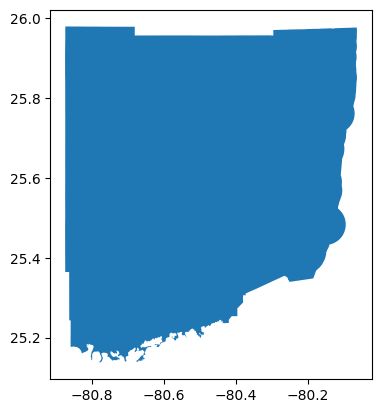

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the giant map of all US Counties
counties = gpd.read_file("tl_2023_us_county.shp")

# 2. Filter the map to ONLY show Miami-Dade County in Florida (Florida's state code is 12)
miami = counties[(counties['NAME'] == 'Miami-Dade') & (counties['STATEFP'] == '12')]

# 3. Draw a quick plot of the county to make sure it worked
miami.plot()
plt.show()

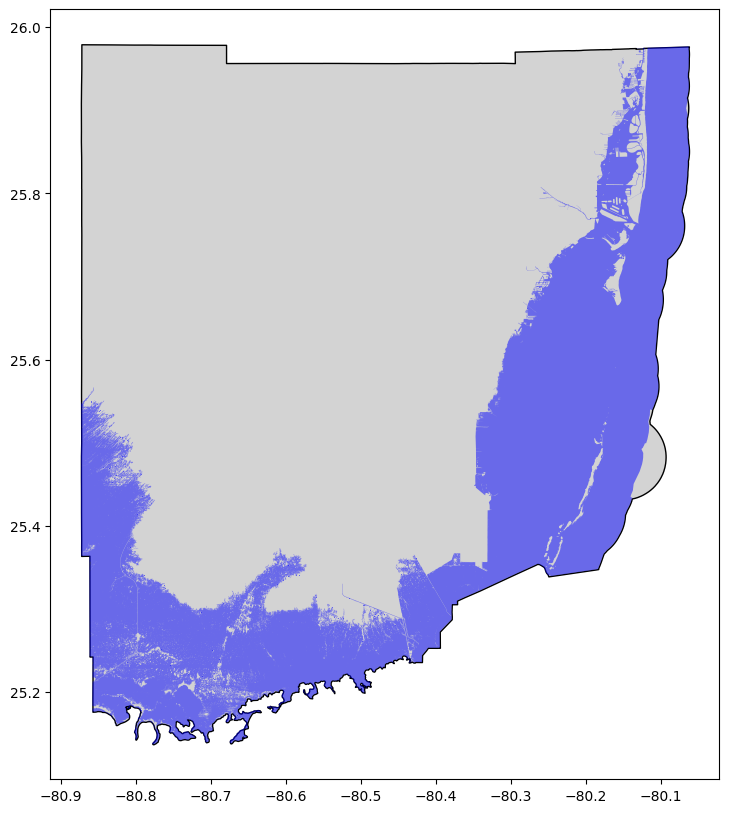

In [2]:
# 1. Load the specific 1-foot sea level rise layer from the GeoPackage
slr_data = gpd.read_file("FL_SE_slr_final_dist.gpkg", layer="FL_SE_slr_1_0ft")

# 2. Make sure the map coordinates match perfectly so they actually line up
if slr_data.crs != miami.crs:
    slr_data = slr_data.to_crs(miami.crs)

# 3. Use CLIP instead of overlay (this is 100x faster for cookie-cutting)
miami_flood = gpd.clip(slr_data, miami)

# 4. Plot them together!
fig, ax = plt.subplots(figsize=(10, 10))
miami.plot(ax=ax, color='lightgrey', edgecolor='black')
miami_flood.plot(ax=ax, color='blue', alpha=0.5) 
plt.show()

In [4]:
%pip install rasterio

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 158.1 MB/s  0:00:00m0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [rasterio]4/5 [rasterio]
Note: you may need to restart the kernel to use updated packages.


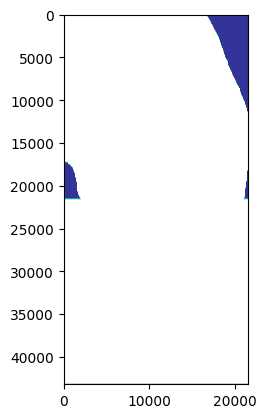

<AxesSubplot: >

In [5]:
import rasterio
from rasterio.merge import merge
from rasterio.plot import show
import glob

# 1. Find all 8 of your .tif files in your Capstone Project folder
tif_files = glob.glob("*.tif")

# 2. Open all of them so Python can read the data
src_files_to_mosaic = []
for fp in tif_files:
    src = rasterio.open(fp)
    src_files_to_mosaic.append(src)

# 3. Stitch them together into one giant map
mosaic, out_trans = merge(src_files_to_mosaic)

# 4. Save this new stitched map to your folder so you only ever have to do this once
out_meta = src.meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans
})

with rasterio.open("miami_merged_elevation.tif", "w", **out_meta) as dest:
    dest.write(mosaic)

# 5. Plot the final stitched map on the screen to verify it worked
show(mosaic, cmap='terrain')

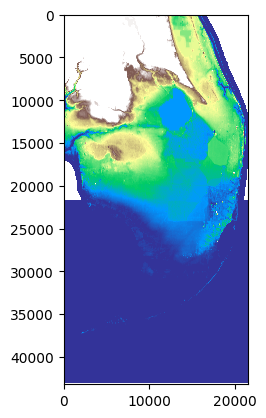

<AxesSubplot: >

In [6]:
import numpy as np
from rasterio.plot import show

# 1. Hide the fake -9999 "No Data" numbers by turning them into NaNs (Not a Number)
plot_data = np.where(mosaic < -100, np.nan, mosaic)

# 2. Plot it again, telling Python to only look at realistic elevations (0 to 15 meters)
show(plot_data, cmap='terrain', vmin=0, vmax=15)

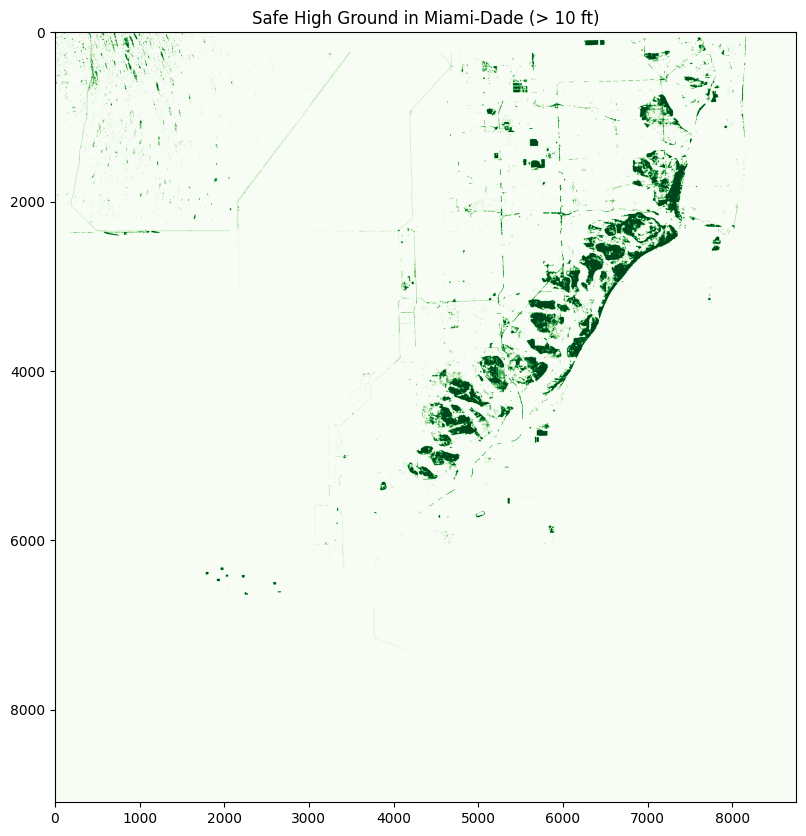

In [7]:
import rasterio
from rasterio.mask import mask
import numpy as np
import matplotlib.pyplot as plt

# 1. Open your newly stitched map
with rasterio.open("miami_merged_elevation.tif") as src:
    # 2. Use the 'miami' county shape as a cookie cutter to clip the raster
    out_image, out_transform = mask(src, miami.geometry, crop=True)
    out_meta = src.meta

# 3. Filter the elevation! 
# We tell Python: If the elevation is greater than 3 meters (~10 feet), label it '1' (Safe). 
# If it is lower than 3 meters, label it '0' (Unsafe).
safe_elevation = np.where(out_image > 3.0, 1, 0)

# 4. Plot the results
fig, ax = plt.subplots(figsize=(10, 10))
# Plot the safe ground in green
plt.imshow(safe_elevation[0], cmap='Greens')
plt.title("Safe High Ground in Miami-Dade (> 10 ft)")
plt.show()

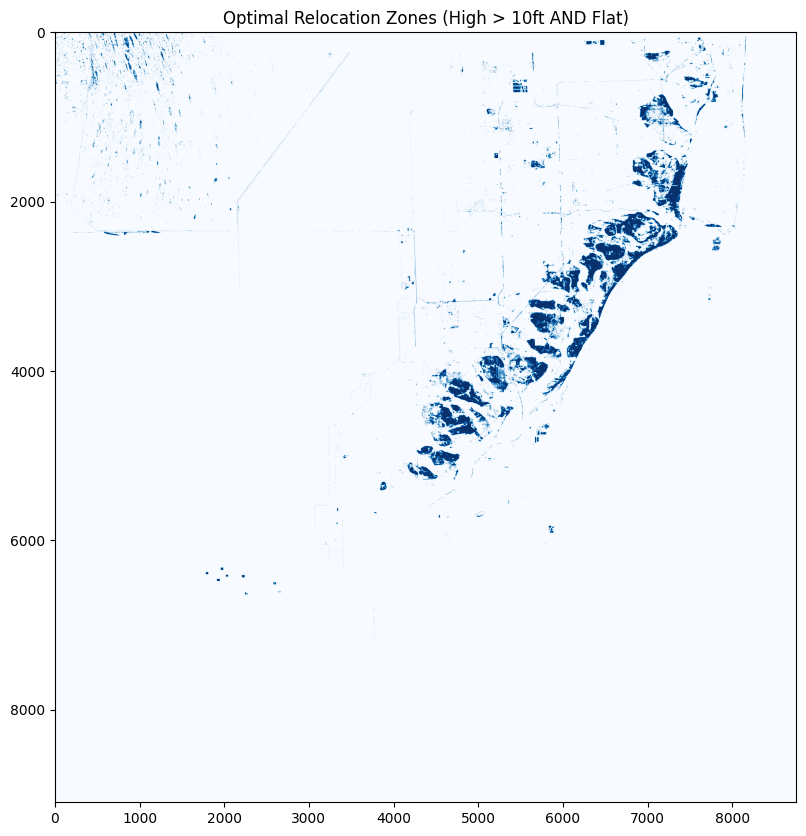

In [8]:
# 1. Calculate the slope to find how steep the ground is
# np.gradient looks at the elevation difference between neighboring pixels
dy, dx = np.gradient(out_image[0])
slope = np.sqrt(dx**2 + dy**2)

# 2. Filter for flat ground! 
# We'll consider a very low slope threshold to be "flat and buildable"
# '1' means flat, '0' means too steep
flat_ground = np.where(slope < 0.5, 1, 0)

# 3. Map Algebra: Combine both maps to find the exact Relocation Zones
# We multiply the two layers. 1 * 1 = 1 (Safe & Flat). 
# If it's low ground (0) or steep ground (0), it gets multiplied out to 0.
safe_and_flat = safe_elevation[0] * flat_ground

# 4. Plot the final Relocation Zone map!
fig, ax = plt.subplots(figsize=(10, 10))
# Let's plot this one in a nice dark blue to stand out
plt.imshow(safe_and_flat, cmap='Blues')
plt.title("Optimal Relocation Zones (High > 10ft AND Flat)")
plt.show()

Pulling population data from the Census API...


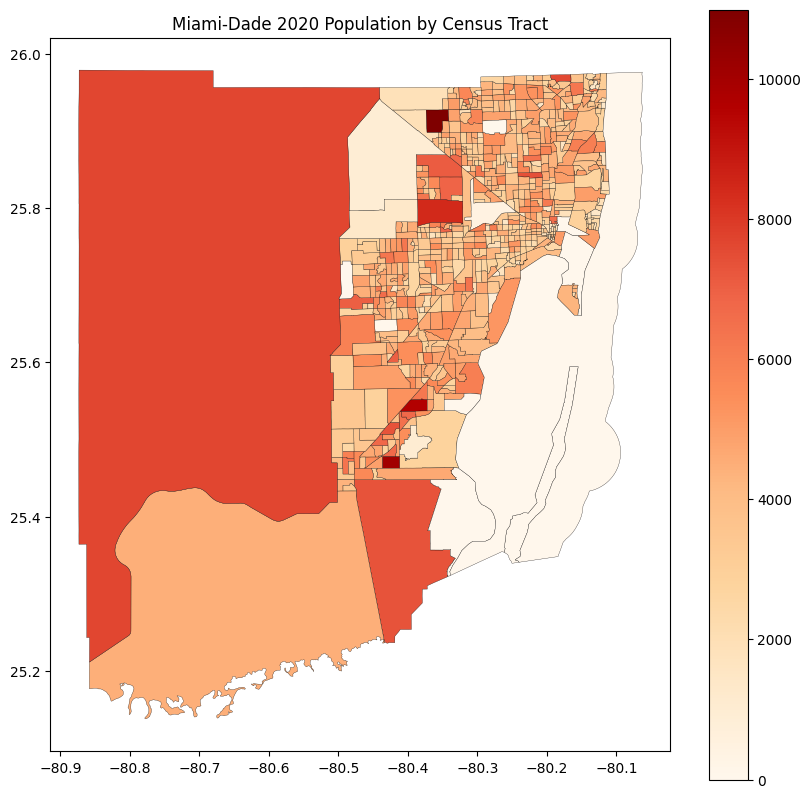

In [9]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Download the neighborhood boundaries (Census Tracts) for Florida directly from the government
print("Downloading Census Tract boundaries...")
tracts = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_12_tract.zip")

# Filter for just Miami-Dade County (County code '086')
miami_tracts = tracts[tracts['COUNTYFP'] == '086']

# 2. Rip the 2020 Total Population numbers straight from the US Census API
print("Pulling population data from the Census API...")
url = "https://api.census.gov/data/2020/dec/pl?get=P1_001N&for=tract:*&in=state:12&in=county:086"
pop_data = pd.read_json(url)

# Clean up the API data table so it's readable
pop_data.columns = pop_data.iloc[0]
pop_data = pop_data[1:]
pop_data = pop_data.rename(columns={'P1_001N': 'Population'})
pop_data['Population'] = pop_data['Population'].astype(int)

# 3. Glue the population numbers to the map boundaries!
miami_pop_map = miami_tracts.merge(pop_data, left_on='TRACTCE', right_on='tract')

# 4. Plot a population heatmap to prove it worked
fig, ax = plt.subplots(figsize=(10, 10))
miami_pop_map.plot(column='Population', cmap='OrRd', legend=True, ax=ax, edgecolor='black', linewidth=0.2)
plt.title("Miami-Dade 2020 Population by Census Tract")
plt.show()

🔥 FINAL ANALYSIS RESULT 🔥
A 1-foot sea level rise in Miami-Dade County will permanently displace approximately 135,090 people.


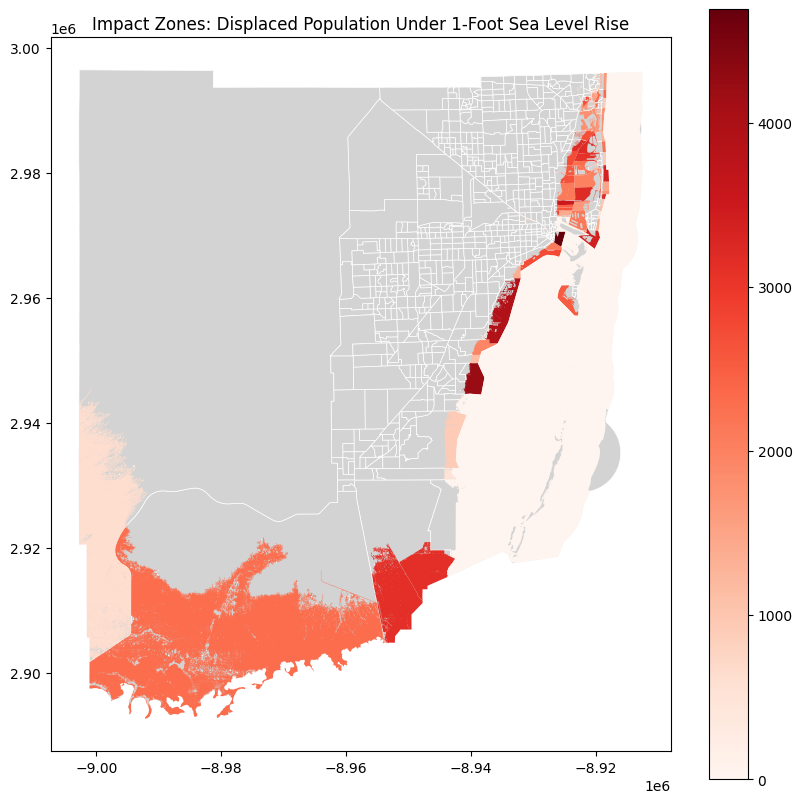

In [10]:
import warnings
warnings.filterwarnings('ignore') # Hides annoying math warnings

# 1. To calculate area accurately, we project both maps to Web Mercator (meters instead of degrees)
miami_pop_map = miami_pop_map.to_crs(epsg=3857)
miami_flood = miami_flood.to_crs(epsg=3857)

# 2. Calculate the original total area of every single neighborhood
miami_pop_map['orig_area'] = miami_pop_map.geometry.area

# 3. THE INTERSECT! Smash the flood map into the population map
flooded_tracts = gpd.overlay(miami_pop_map, miami_flood, how='intersection')

# 4. Calculate the area of the water that is specifically inside each neighborhood
flooded_tracts['flood_area'] = flooded_tracts.geometry.area

# 5. Math time: Calculate the percentage flooded, then multiply by the population
flooded_tracts['pct_flooded'] = flooded_tracts['flood_area'] / flooded_tracts['orig_area']
flooded_tracts['displaced_people'] = flooded_tracts['Population'] * flooded_tracts['pct_flooded']

# 6. Add it all up to get your final disaster metric!
total_displaced = int(flooded_tracts['displaced_people'].sum())

print(f"🔥 FINAL ANALYSIS RESULT 🔥")
print(f"A 1-foot sea level rise in Miami-Dade County will permanently displace approximately {total_displaced:,} people.")

# 7. Plot the true impact map
fig, ax = plt.subplots(figsize=(10, 10))
miami_pop_map.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)
flooded_tracts.plot(column='displaced_people', cmap='Reds', legend=True, ax=ax)
plt.title("Impact Zones: Displaced Population Under 1-Foot Sea Level Rise")
plt.show()